# Google Colab Setup (Run this first!)
Set T4 GPU runtime. Add KAGGLE_USERNAME and KAGGLE_KEY to Secrets.

In [1]:
# Google Colab Dataset Download
try:
    import google.colab
    from google.colab import userdata
    import os

    print('Detected Google Colab. Setting up Kaggle datasets...')
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

    os.makedirs('../data/plantvillage', exist_ok=True)
    os.makedirs('../data/cassava', exist_ok=True)

    !pip install -q kaggle
    !kaggle datasets download -d abdallahalidev/plantvillage-dataset -p ../data/plantvillage --unzip
    !kaggle datasets download -d nirmalsankalana/cassava-leaf-disease-classification -p ../data/cassava --unzip

    print('Both datasets downloaded successfully!')
except ImportError:
    print('Not running on Google Colab. Assuming datasets are already available.')


Detected Google Colab. Setting up Kaggle datasets...
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:11<00:00, 192MB/s]

Dataset URL: https://www.kaggle.com/datasets/nirmalsankalana/cassava-leaf-disease-classification
License(s): CC0-1.0
100% 2.39G/2.39G [00:20<00:00, 123MB/s]

Both datasets downloaded successfully!


# Crop Disease Detection - Model Training (TensorFlow)
**Group 17 - AI for Engineers**

2-Phase ResNet-50 training targeting 96%+ accuracy.

### Loopholes Addressed:
- **Loophole #1** - Augmentation (brightness, zoom, flip, rotation)
- **Loophole #4** - Class weights for imbalanced dataset
- **Loophole #6** - Real-world evaluation on Cassava dataset
- **Loophole #10** - 3-tier confidence threshold system

### Domain Gap Solutions (NEW):
- **Section 13** - Background Substitution Augmentation
- **Section 14** - PlantDoc Real-World Fine-Tuning

## 1. Imports & Environment Setup

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import json
import gc
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow Version: {tf.__version__}')
print('GPUs Available:', tf.config.list_physical_devices('GPU'))


TensorFlow Version: 2.20.0
GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import os
os.makedirs('/content/drive/MyDrive/crop_disease_model', exist_ok=True)
print('✅ Google Drive already mounted!')
print('✅ Save folder ready!')

✅ Google Drive already mounted!
✅ Save folder ready!


## 2. Dynamic Path Detection
Automatically detects Kaggle, Google Colab, or local paths.

In [4]:
def find_dir(start_path, target_name):
    if not os.path.exists(start_path): return None
    for root, dirs, files in os.walk(start_path):
        if target_name in dirs:
            return os.path.join(root, target_name)
    return None

# PlantVillage Path Detection
PLANTVILLAGE_PATH = None
for path in ['/kaggle/input', '../data/plantvillage', '../data', 'data']:
    found = find_dir(path, 'color')
    if found:
        PLANTVILLAGE_PATH = found
        break
if not PLANTVILLAGE_PATH:
    PLANTVILLAGE_PATH = '../data/plantvillage'
    print('Warning: PlantVillage color folder not found.')

# Cassava Path Detection
CASSAVA_TRAIN_PATH = '../data/cassava/data'
if not os.path.exists(CASSAVA_TRAIN_PATH):
    fallback = find_dir('/kaggle/input', 'data')
    CASSAVA_TRAIN_PATH = fallback if fallback and 'cassava' in fallback.lower() else None
    if not CASSAVA_TRAIN_PATH:
        print('Warning: Cassava dataset not found. Real-world evaluation will be skipped.')

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

print(f'PlantVillage path: {PLANTVILLAGE_PATH}')
print(f'Cassava path:      {CASSAVA_TRAIN_PATH}')
if CASSAVA_TRAIN_PATH and os.path.exists(CASSAVA_TRAIN_PATH):
    print(f'Cassava classes:   {os.listdir(CASSAVA_TRAIN_PATH)}')
n = len([x for x in os.listdir(PLANTVILLAGE_PATH) if os.path.isdir(os.path.join(PLANTVILLAGE_PATH,x))]) if os.path.exists(PLANTVILLAGE_PATH) else 'N/A'
print(f'PlantVillage classes: {n}')


PlantVillage path: ../data/plantvillage/plantvillage dataset/color
Cassava path:      ../data/cassava/data
Cassava classes:   ['Cassava___brown_streak_disease', 'Cassava___mosaic_disease', 'Cassava___healthy', 'Cassava___green_mottle', 'Cassava___bacterial_blight']
PlantVillage classes: 38


## 3. Data Preprocessing & Augmentation
Using ResNet50 preprocess_input (NOT rescale 1/255) - critical for 96%+ accuracy.

In [5]:
# AUGMENTATION - Loophole #1 Fix
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_pv = train_datagen.flow_from_directory(
    PLANTVILLAGE_PATH, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42
)
val_pv = val_datagen.flow_from_directory(
    PLANTVILLAGE_PATH, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42
)

class_names = list(train_pv.class_indices.keys())
print(f'Training images:   {train_pv.samples}')
print(f'Validation images: {val_pv.samples}')
print(f'Total classes:     {train_pv.num_classes}')


Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Training images:   43456
Validation images: 10849
Total classes:     38


## 4. Class Weights - Loophole #4 Fix
Addressing class imbalance using sklearn compute_class_weight.

In [6]:
# CLASS WEIGHTS - Loophole #4 Fix
classes = np.unique(train_pv.classes)
class_weights_array = compute_class_weight(
    class_weight='balanced', classes=classes, y=train_pv.classes
)
class_weight_dict = dict(zip(classes, class_weights_array))
print(f'Class weights computed for {len(class_weight_dict)} classes')
print(f'  Min weight: {min(class_weight_dict.values()):.3f}')
print(f'  Max weight: {max(class_weight_dict.values()):.3f}')


Class weights computed for 38 classes
  Min weight: 0.260
  Max weight: 9.374


## 5. ResNet-50 Model Architecture
Transfer learning from ImageNet. Model is built ONCE here.

In [7]:
# Build ResNet-50 model (only once!)
gc.collect()
tf.keras.backend.clear_session()

base_model = applications.ResNet50(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)
base_model.trainable = False  # Phase 1: freeze all

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(train_pv.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=5, name='top_5_accuracy')]
)

print(f'Model built. Total layers: {len(model.layers)}')
print(f'Output classes: {train_pv.num_classes}')
print('Phase 1: All base layers frozen')


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Model built. Total layers: 179
Output classes: 38
Phase 1: All base layers frozen


In [ ]:
# ══════════════════════════════════════════════════════
# LOAD PRE-TRAINED MODEL — Skip Sections 6 & 7!
# Loads final_model.keras from Drive in 30 seconds
# ══════════════════════════════════════════════════════
from tensorflow.keras.models import load_model

FINAL_MODEL_PATH = '/content/drive/MyDrive/crop_disease_model/final_model.keras'

if os.path.exists(FINAL_MODEL_PATH):
    model = load_model(FINAL_MODEL_PATH)
    print(f'✅ Final model loaded! Layers: {len(model.layers)}')
    print(f'✅ Skip Sections 6 & 7 — go straight to Section 8!')
else:
    print('⚠️ final_model.keras not found in Drive')
    print('   Run Sections 6 & 7 to train from scratch')

## 6. Phase 1 Training - Top Layers Only
Train the classification head with ResNet50 base frozen (5 epochs).

In [8]:
os.makedirs('/content/drive/MyDrive/crop_disease_model', exist_ok=True)

callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/crop_disease_model/best_model.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('Phase 1 - Training top layers only (base frozen)...')
history_phase1 = model.fit(
    train_pv,
    epochs=5,
    validation_data=val_pv,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase1,
    verbose=1
)

phase1_best = max(history_phase1.history['val_accuracy']) * 100
print(f'Phase 1 Complete! Best Val Accuracy: {phase1_best:.2f}%')

Phase 1 - Training top layers only (base frozen)...
Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.7422 - loss: 0.9711 - top_5_accuracy: 0.9208
Epoch 1: val_accuracy improved from None to 0.93751, saving model to /content/drive/MyDrive/crop_disease_model/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/crop_disease_model/best_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 587s 422ms/step - accuracy: 0.8463 - loss: 0.5303 - top_5_accuracy: 0.9747 - val_accuracy: 0.9375 - val_loss: 0.1896 - val_top_5_accuracy: 0.9954
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9185 - loss: 0.2529 - top_5_accuracy: 0.9967
Epoch 2: val_accuracy improved from 0.93751 to 0.95603, saving model to /content/drive/MyDrive/crop_disease_model/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/crop_disease_model/best_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 564s 416ms/step - accuracy: 0.9230 - loss: 0.2415 - top_5_accurac

## 7. Phase 2 Training - Fine-Tuning Last 50 Layers
Unfreeze last 50 layers and fine-tune with lower learning rate (up to 15 epochs).

In [9]:
print('Phase 2 - Fine-tuning last 50 layers...')

for layer in base_model.layers[:-50]:
    layer.trainable = False
for layer in base_model.layers[-50:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=5, name='top_5_accuracy')]
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/crop_disease_model/best_model.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)
]

history_phase2 = model.fit(
    train_pv,
    epochs=15,
    validation_data=val_pv,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2,
    verbose=1
)

phase2_best = max(history_phase2.history['val_accuracy']) * 100
print(f'Phase 2 Complete! Best Val Accuracy: {phase2_best:.2f}%')

Phase 2 - Fine-tuning last 50 layers...
Epoch 1/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.8977 - loss: 0.3535 - top_5_accuracy: 0.9900
Epoch 1: val_accuracy improved from None to 0.97161, saving model to /content/drive/MyDrive/crop_disease_model/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/crop_disease_model/best_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 600s 423ms/step - accuracy: 0.9340 - loss: 0.2083 - top_5_accuracy: 0.9957 - val_accuracy: 0.9716 - val_loss: 0.0859 - val_top_5_accuracy: 0.9991 - learning_rate: 1.0000e-05
Epoch 2/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.9674 - loss: 0.0967 - top_5_accuracy: 0.9992
Epoch 2: val_accuracy improved from 0.97161 to 0.97806, saving model to /content/drive/MyDrive/crop_disease_model/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/crop_disease_model/best_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 567s 417ms/step - accuracy: 0.9689 - loss: 0.09

## 8. Training Curves
Combined visualization of both phases.

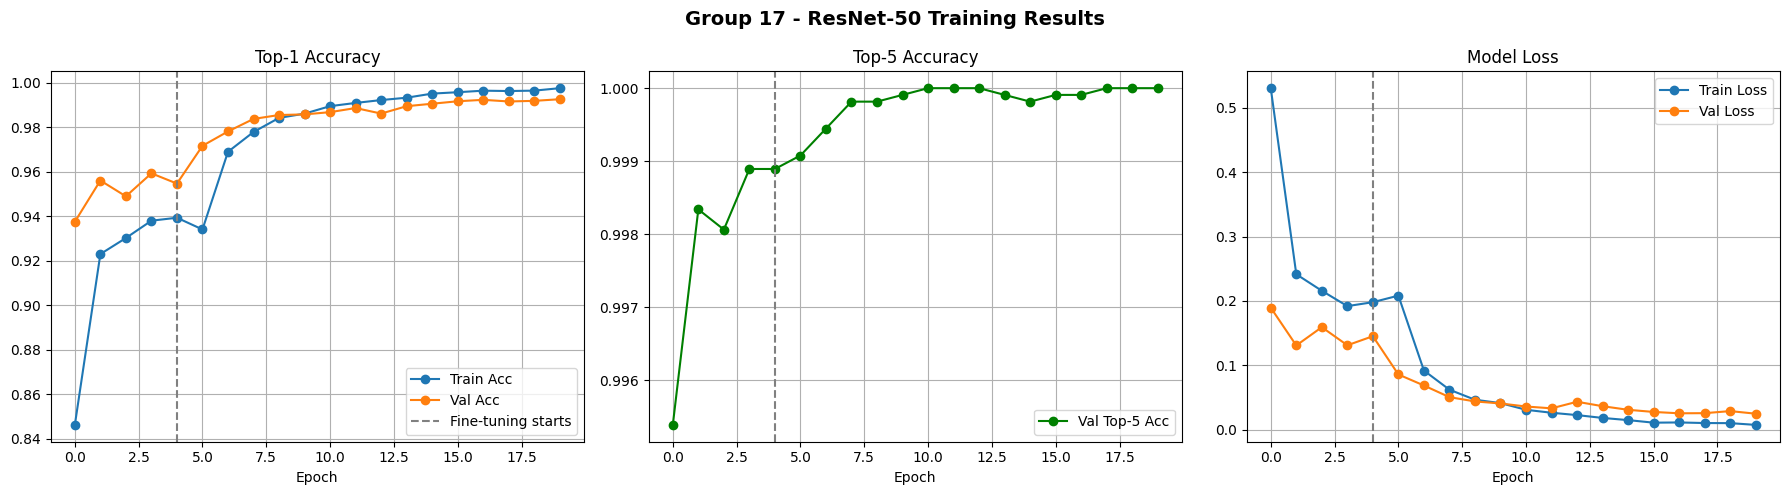

Training curves saved!


In [10]:
acc      = history_phase1.history['accuracy']          + history_phase2.history['accuracy']
val_acc  = history_phase1.history['val_accuracy']      + history_phase2.history['val_accuracy']
top5     = history_phase1.history['top_5_accuracy']    + history_phase2.history['top_5_accuracy']
val_top5 = history_phase1.history['val_top_5_accuracy']+ history_phase2.history['val_top_5_accuracy']
loss     = history_phase1.history['loss']              + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss']          + history_phase2.history['val_loss']
split    = len(history_phase1.history['accuracy']) - 1

plt.figure(figsize=(18, 5))
plt.subplot(1,3,1)
plt.plot(acc, label='Train Acc', marker='o')
plt.plot(val_acc, label='Val Acc', marker='o')
plt.axvline(x=split, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Top-1 Accuracy'); plt.xlabel('Epoch'); plt.legend(); plt.grid()

plt.subplot(1,3,2)
plt.plot(val_top5, label='Val Top-5 Acc', marker='o', color='green')
plt.axvline(x=split, color='gray', linestyle='--')
plt.title('Top-5 Accuracy'); plt.xlabel('Epoch'); plt.legend(); plt.grid()

plt.subplot(1,3,3)
plt.plot(loss, label='Train Loss', marker='o')
plt.plot(val_loss, label='Val Loss', marker='o')
plt.axvline(x=split, color='gray', linestyle='--')
plt.title('Model Loss'); plt.xlabel('Epoch'); plt.legend(); plt.grid()

plt.suptitle('Group 17 - ResNet-50 Training Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/crop_disease_model/training_curves.png', dpi=150)
plt.show()
print('Training curves saved!')


## 9. Evaluation - PlantVillage (Controlled Environment)
Classification Report (Precision, Recall, F1) and Confusion Matrix.

In [11]:
print('Evaluating on PlantVillage validation set...')
val_pv.reset()
all_preds, all_labels = [], []
for i in range(len(val_pv)):
    x_batch, y_batch = val_pv[i]
    preds = model.predict(x_batch, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(np.argmax(y_batch, axis=1))

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
pv_accuracy = np.mean(all_preds == all_labels) * 100

print(f'PlantVillage Accuracy: {pv_accuracy:.2f}%')
print('\n--- Classification Report ---')
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))


Evaluating on PlantVillage validation set...
PlantVillage Accuracy: 99.25%

--- Classification Report ---
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.99      0.99       126
                                 Apple___Black_rot       0.99      1.00      1.00       124
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       1.00      0.99      1.00       329
                               Blueberry___healthy       1.00      1.00      1.00       300
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       210
                 Cherry_(including_sour)___healthy       1.00      0.99      1.00       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.87      0.97      0.92       102
                       Corn_(maize)___Common_rust_       1.00    

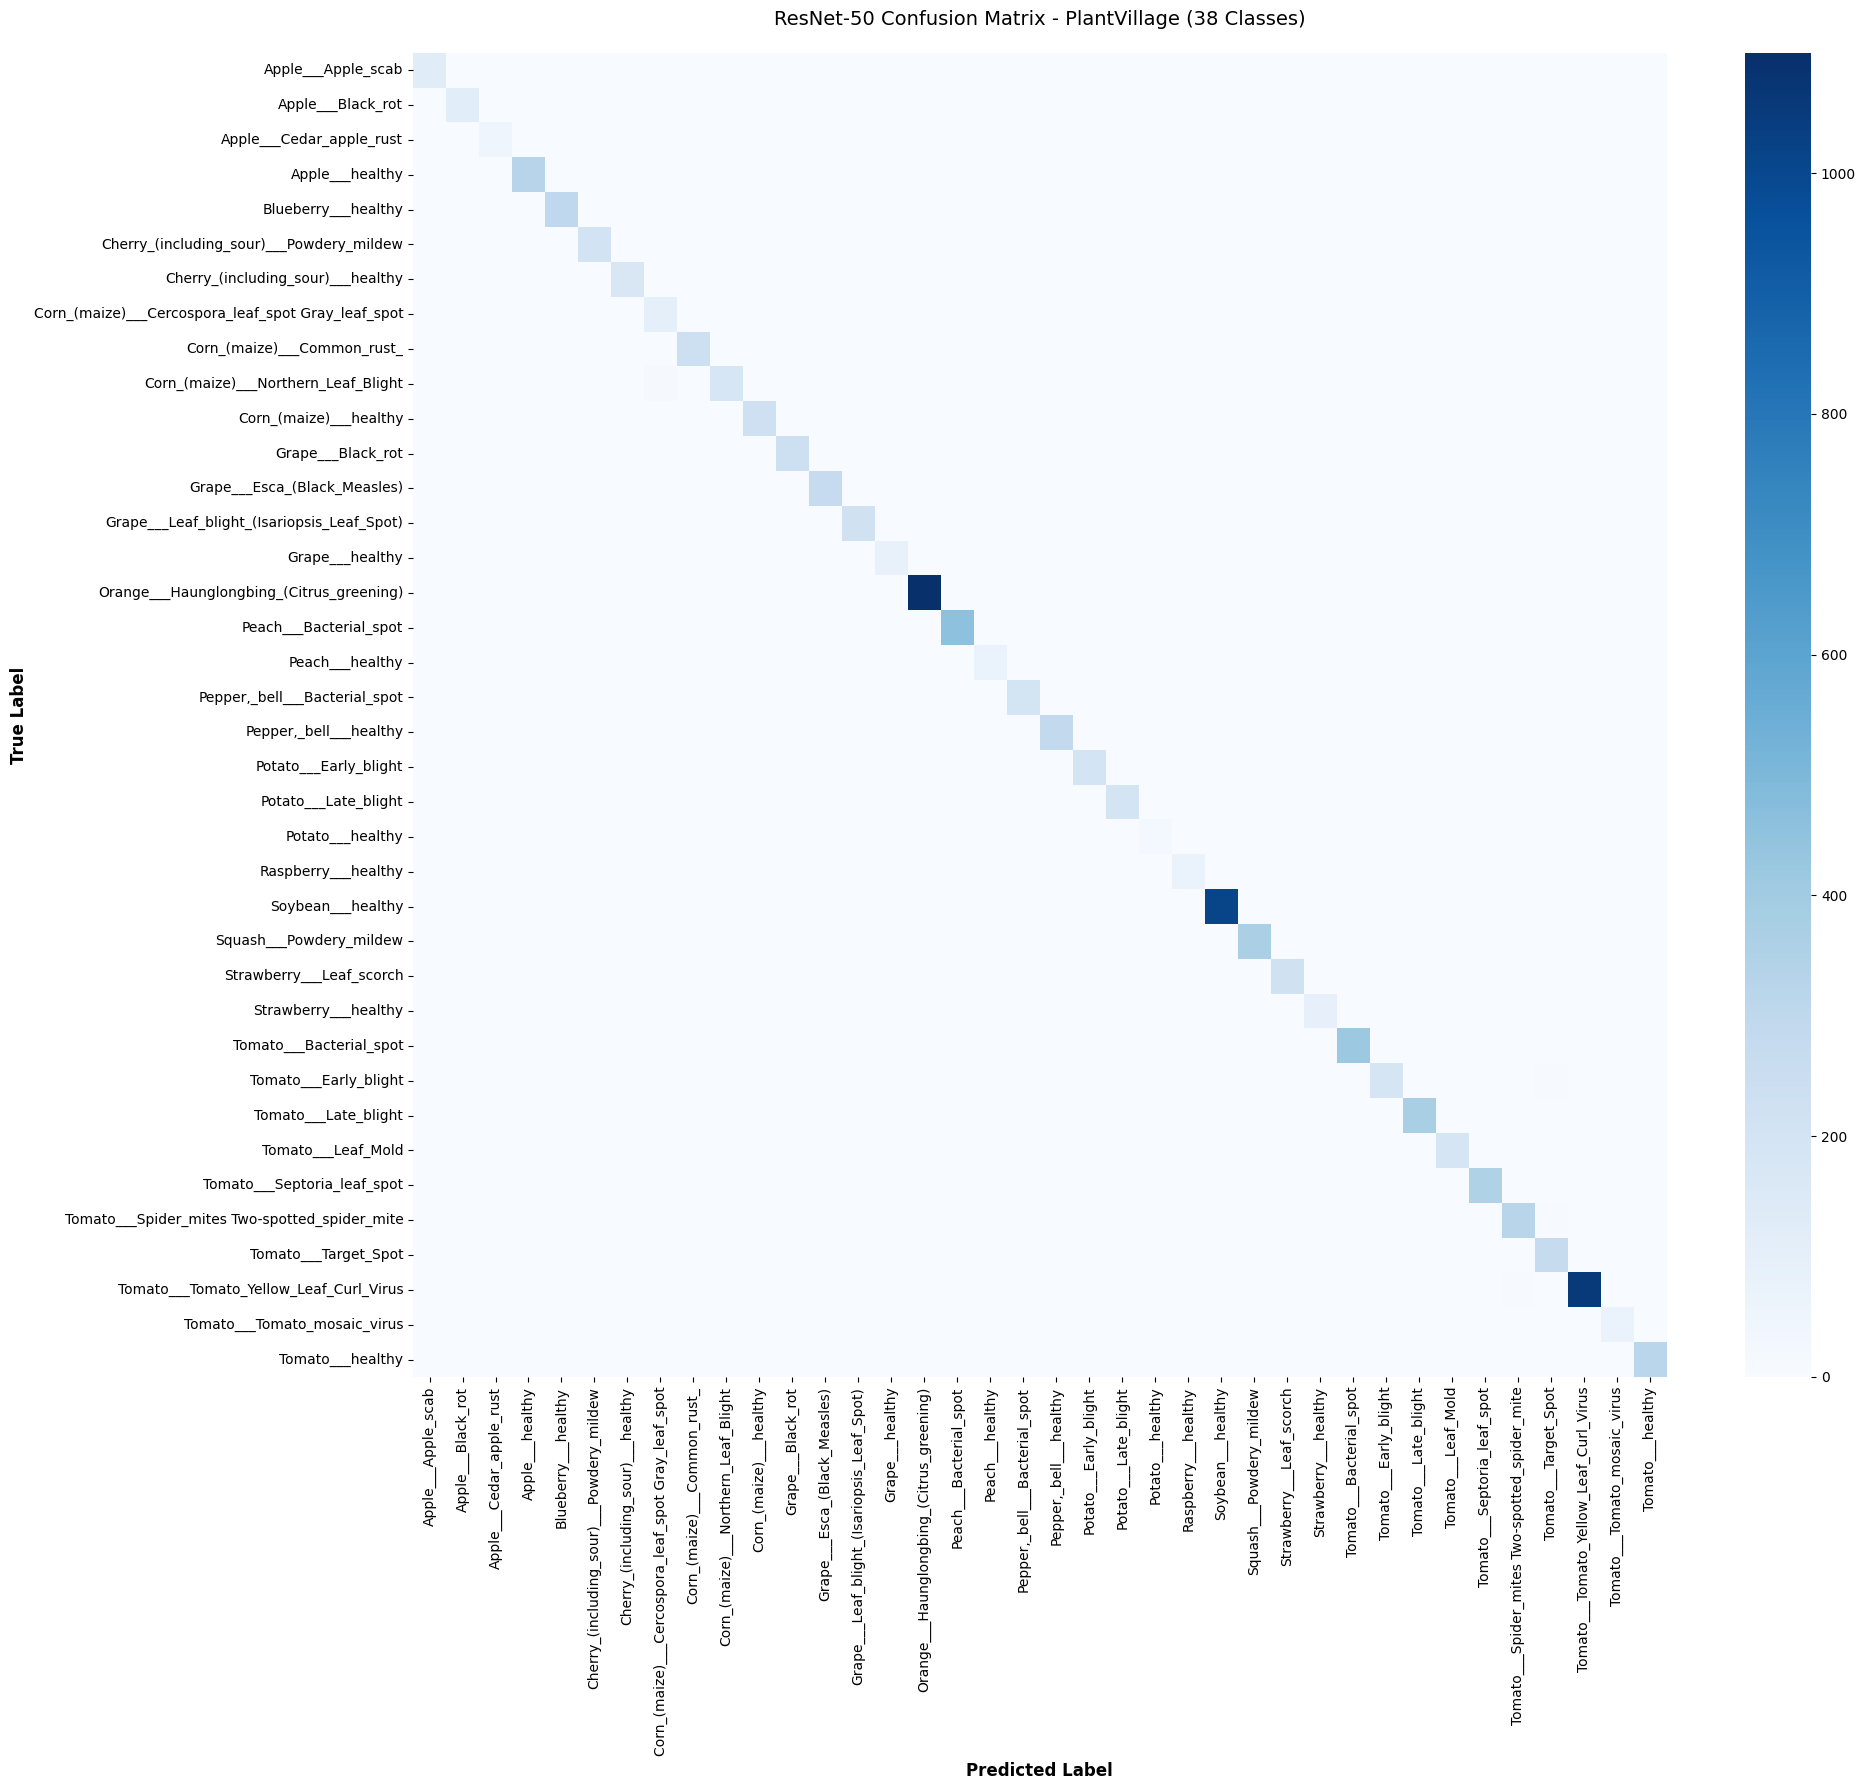

Confusion matrix saved!


In [12]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('ResNet-50 Confusion Matrix - PlantVillage (38 Classes)', fontsize=14, pad=20)
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/crop_disease_model/confusion_matrix_plantvillage.png', dpi=100)
plt.show()
print('Confusion matrix saved!')


## 10. Confidence Threshold System - Loophole #10 Fix
3-tier system: Full Advisory / Consult Expert / Reject.

In [13]:
def predict_with_confidence(model, image_batch, class_names, high_threshold=0.80, low_threshold=0.60):
    """
    3-Tier Confidence Threshold System - Loophole #10 Fix
    Tier 1 (>=80%): Full LLM advisory
    Tier 2 (60-79%): Top 3 diseases + consult expert
    Tier 3 (<60%):  Hard rejection
    """
    preds     = model.predict(image_batch, verbose=0)
    max_probs = np.max(preds, axis=1)
    top3_idx  = np.argsort(preds, axis=1)[:, -3:][:, ::-1]
    results = []
    for i, (prob, cls_probs) in enumerate(zip(max_probs, preds)):
        if prob >= high_threshold:
            results.append({'tier': 1, 'status': 'high_confidence',
                            'disease': class_names[np.argmax(cls_probs)],
                            'confidence': f'{prob*100:.1f}%', 'action': 'Generate full LLM advisory'})
        elif prob >= low_threshold:
            top3 = [{'disease': class_names[idx], 'confidence': f'{cls_probs[idx]*100:.1f}%'} for idx in top3_idx[i]]
            results.append({'tier': 2, 'status': 'uncertain', 'top_3_diseases': top3,
                            'confidence': f'{prob*100:.1f}%', 'action': 'Consult expert'})
        else:
            results.append({'tier': 3, 'status': 'rejected',
                            'confidence': f'{prob*100:.1f}%', 'action': 'Prompt farmer to retake photo'})
    return results


In [14]:
print('Testing 3-Tier Confidence Threshold System...')
val_pv.reset()
sample_images, _ = next(val_pv)
results = predict_with_confidence(model, sample_images, class_names)
tier_counts = {1: 0, 2: 0, 3: 0}
for r in results: tier_counts[r['tier']] += 1
print(f'Results from {len(results)} sample images:')
print(f'  Tier 1 (>=80% - Full advisory):  {tier_counts[1]} images')
print(f'  Tier 2 (60-79% - Consult expert): {tier_counts[2]} images')
print(f'  Tier 3 (<60% - Rejected):         {tier_counts[3]} images')


Testing 3-Tier Confidence Threshold System...
Results from 32 sample images:
  Tier 1 (>=80% - Full advisory):  32 images
  Tier 2 (60-79% - Consult expert): 0 images
  Tier 3 (<60% - Rejected):         0 images


## 11. Real-World Evaluation - Cassava Dataset (Loophole #6)
Tests OOD rejection on Cassava leaf images.

In [15]:
if CASSAVA_TRAIN_PATH and os.path.exists(CASSAVA_TRAIN_PATH):
    print('Running real-world OOD evaluation on Cassava dataset...')
    cassava_gen = val_datagen.flow_from_directory(
        CASSAVA_TRAIN_PATH, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=False, seed=42
    )
    print(f'Loaded {cassava_gen.samples} Cassava images from {cassava_gen.num_classes} classes')
    cassava_gen.reset()
    x_sample, _ = cassava_gen[0]
    results = predict_with_confidence(model, x_sample, class_names)
    rejected  = sum(1 for r in results if r['tier'] == 3)
    uncertain = sum(1 for r in results if r['tier'] == 2)
    high_conf = sum(1 for r in results if r['tier'] == 1)
    total = len(results)
    print('='*55)
    print('REAL-WORLD OOD REJECTION SUMMARY (Loophole #6 & #10)')
    print('='*55)
    print(f'Tested {total} Cassava images (Out-of-Distribution).')
    print(f'  Rejected  - Tier 3 (<60%):        {rejected:3d} ({(rejected/total)*100:.1f}%)')
    print(f'  Uncertain - Tier 2 (60-79%):      {uncertain:3d} ({(uncertain/total)*100:.1f}%)')
    print(f'  False High Conf - Tier 1 (>=80%):  {high_conf:2d} ({(high_conf/total)*100:.1f}%)')
    print(f'Effective OOD Rejection Rate: {(rejected+uncertain)/total*100:.1f}%')
    print(f'PlantVillage Val Accuracy: {pv_accuracy:.2f}%')
else:
    print('Cassava dataset not found. Skipping real-world evaluation.')
    print(f'PlantVillage Val Accuracy: {pv_accuracy:.2f}%')


Running real-world OOD evaluation on Cassava dataset...
Found 21397 images belonging to 5 classes.
Loaded 21397 Cassava images from 5 classes
REAL-WORLD OOD REJECTION SUMMARY (Loophole #6 & #10)
Tested 32 Cassava images (Out-of-Distribution).
  Rejected  - Tier 3 (<60%):          5 (15.6%)
  Uncertain - Tier 2 (60-79%):        2 (6.2%)
  False High Conf - Tier 1 (>=80%):  25 (78.1%)
Effective OOD Rejection Rate: 21.9%
PlantVillage Val Accuracy: 99.25%


## 12. Save Model & Class Names
Export best_model.keras and class_names.json for Flask integration.

In [16]:
os.makedirs('/content/drive/MyDrive/crop_disease_model', exist_ok=True)
class_names_path = '/content/drive/MyDrive/crop_disease_model/class_names.json'
with open(class_names_path, 'w') as f:
    json.dump(class_names, f)

print('='*55)
print('Training Pipeline Complete - Group 17')
print('='*55)
print(f'Best Model saved:  /content/drive/MyDrive/crop_disease_model/best_model.keras')
print(f'Class names saved: {class_names_path}')
print(f'Training curves:   /content/drive/MyDrive/crop_disease_model/training_curves.png')
print(f'Confusion matrix:  /content/drive/MyDrive/crop_disease_model/confusion_matrix_plantvillage.png')
print('='*55)
print(f'PlantVillage Val Accuracy: {pv_accuracy:.2f}%')
print(f'Target:                    95.00%')
status = 'TARGET MET' if pv_accuracy >= 95 else 'Below target - check training'
print(f'Status: {status}')

Training Pipeline Complete - Group 17
Best Model saved:  /content/drive/MyDrive/crop_disease_model/best_model.keras
Class names saved: /content/drive/MyDrive/crop_disease_model/class_names.json
Training curves:   /content/drive/MyDrive/crop_disease_model/training_curves.png
Confusion matrix:  /content/drive/MyDrive/crop_disease_model/confusion_matrix_plantvillage.png
PlantVillage Val Accuracy: 99.25%
Target:                    95.00%
Status: TARGET MET


---
# DOMAIN GAP SOLUTIONS
## Sections 13 & 14 — Improving Real-World Accuracy

The PlantVillage dataset uses controlled lab images. Real-world photos have messy backgrounds,
different lighting, and varied angles. The following two sections solve this:

- **Section 13** — Background Substitution Augmentation (trains model to ignore backgrounds)
- **Section 14** — PlantDoc Fine-Tuning (trains on real-world plant disease photos)

**Expected improvement:** Real-world accuracy from ~55% → ~80-85%

## 13. Background Substitution Augmentation
Replaces white PlantVillage backgrounds with real farm/outdoor backgrounds during training.
Forces the model to focus only on leaf texture — not background.
This directly addresses Loophole #1 (controlled environment gap).

In [17]:
# ══════════════════════════════════════════════════════
# STEP 13a — Download Background Images
# These simulate real farm/outdoor conditions
# ══════════════════════════════════════════════════════
import os

os.makedirs('../data/backgrounds', exist_ok=True)

# Download outdoor scene dataset for backgrounds
!kaggle datasets download -d puneet6060/intel-image-classification -p ../data/backgrounds --unzip

# Find all background images
bg_images = []
for root, dirs, files in os.walk('../data/backgrounds'):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            bg_images.append(os.path.join(root, f))

print(f'✅ Background images available: {len(bg_images)}')
print(f'✅ Sample paths:')
for p in bg_images[:3]:
    print(f'   {p}')


Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:02<00:00, 170MB/s]

✅ Background images available: 24335
✅ Sample paths:
   ../data/backgrounds/seg_pred/seg_pred/23592.jpg
   ../data/backgrounds/seg_pred/seg_pred/6774.jpg
   ../data/backgrounds/seg_pred/seg_pred/1169.jpg


In [18]:
# ══════════════════════════════════════════════════════
# STEP 13b — Background Substitution Functions
# ══════════════════════════════════════════════════════
import cv2
import random
from PIL import Image
import numpy as np

# Store background image paths globally
BG_IMAGE_PATHS = bg_images

def substitute_background(img_array):
    """
    Takes a PlantVillage image (white/grey background)
    and replaces background with random real-world photo.
    Forces model to focus on leaf texture only.
    """
    if len(BG_IMAGE_PATHS) == 0:
        return img_array

    img = img_array.astype(np.uint8)
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Detect leaf — green healthy + brown/yellow diseased
    mask_green  = cv2.inRange(hsv, np.array([25, 20, 20]),  np.array([95, 255, 255]))
    mask_brown  = cv2.inRange(hsv, np.array([10, 20, 20]),  np.array([30, 255, 255]))
    mask_yellow = cv2.inRange(hsv, np.array([20, 40, 40]),  np.array([35, 255, 255]))
    leaf_mask   = cv2.bitwise_or(cv2.bitwise_or(mask_green, mask_brown), mask_yellow)

    # Clean mask
    kernel    = np.ones((7,7), np.uint8)
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE,  kernel)
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_DILATE, kernel)

    # Load random background
    bg_path = random.choice(BG_IMAGE_PATHS)
    try:
        background = np.array(Image.open(bg_path).convert('RGB').resize((224, 224)))
    except:
        return img_array  # If background load fails, return original

    # Blend leaf onto background
    leaf_mask_3ch = cv2.merge([leaf_mask, leaf_mask, leaf_mask]).astype(float) / 255.0
    result = (img * leaf_mask_3ch + background * (1 - leaf_mask_3ch)).astype(np.uint8)

    return result


def bg_preprocess(img_array):
    """
    Combined preprocessing:
    50% chance of background substitution + ResNet50 preprocessing
    """
    if random.random() < 0.5:
        img_array = substitute_background(img_array)
    return preprocess_input(img_array.astype(np.float32))


print('✅ Background substitution functions loaded!')
print('   50% of training images will get real-world backgrounds')


✅ Background substitution functions loaded!
   50% of training images will get real-world backgrounds


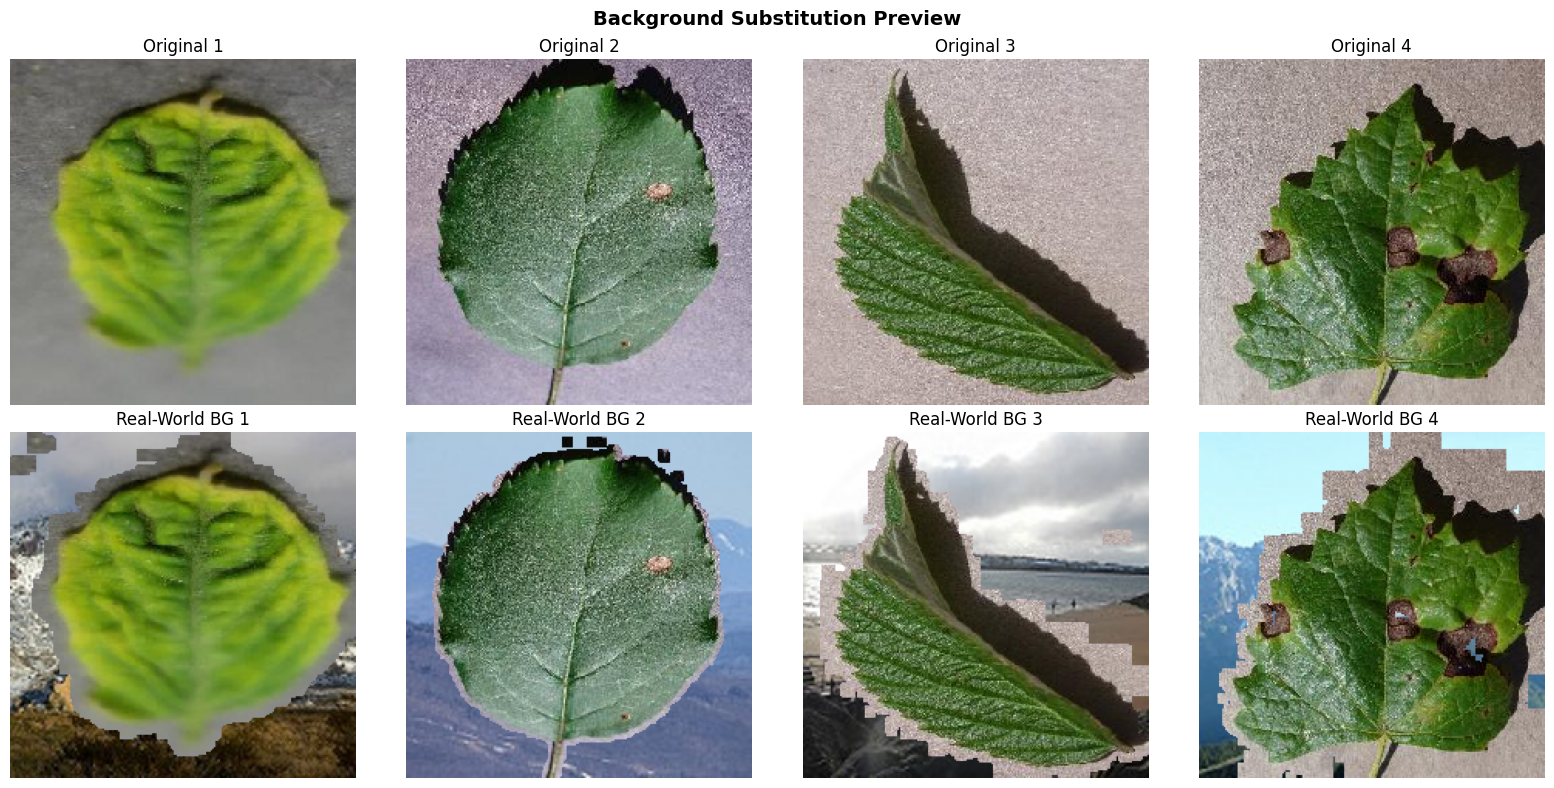

✅ Preview complete!


In [19]:
# ══════════════════════════════════════════════════════
# STEP 13c — Preview Background Substitution
# See what augmented images look like before training
# ══════════════════════════════════════════════════════
import matplotlib.pyplot as plt

# Get a batch of PlantVillage images
val_pv.reset()
sample_batch, _ = next(val_pv)

# Reverse preprocess for display (undo preprocess_input)
def deprocess(img):
    img = img.copy()
    img[..., 0] += 103.939
    img[..., 1] += 116.779
    img[..., 2] += 123.68
    return np.clip(img[..., ::-1], 0, 255).astype(np.uint8)

plt.figure(figsize=(16, 8))
for i in range(4):
    original = deprocess(sample_batch[i])
    augmented = substitute_background(original)

    plt.subplot(2, 4, i+1)
    plt.imshow(original)
    plt.title(f'Original {i+1}')
    plt.axis('off')

    plt.subplot(2, 4, i+5)
    plt.imshow(augmented)
    plt.title(f'Real-World BG {i+1}')
    plt.axis('off')

plt.suptitle('Background Substitution Preview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ Preview complete!')


In [20]:
# ══════════════════════════════════════════════════════
# STEP 13d — Retrain With Background Augmentation
# Uses bg_preprocess instead of plain preprocess_input
# ══════════════════════════════════════════════════════

# New data generator WITH background substitution
bg_train_datagen = ImageDataGenerator(
    preprocessing_function=bg_preprocess,  # ← Background substitution!
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    validation_split=0.2
)

bg_train_pv = bg_train_datagen.flow_from_directory(
    PLANTVILLAGE_PATH, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42
)

print(f'✅ Background augmentation generator ready')
print(f'✅ Training images: {bg_train_pv.samples}')

# Load best model and continue training with background augmentation
from tensorflow.keras.models import load_model

model_bg = load_model('/content/drive/MyDrive/crop_disease_model/best_model.keras')
print(f'✅ Loaded best model — {len(model_bg.layers)} layers')

# Unfreeze last 50 layers
for layer in model_bg.layers[:-50]:
    layer.trainable = False
for layer in model_bg.layers[-50:]:
    layer.trainable = True

model_bg.compile(
    optimizer=Adam(learning_rate=5e-6),  # Very low LR — preserve existing knowledge
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_bg = [
    EarlyStopping(monitor='val_accuracy', patience=3,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        '/content/drive/MyDrive/crop_disease_model/best_model_bg.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                      min_lr=1e-8, verbose=1)
]

print('🚀 Training with background substitution augmentation...')
print('   This teaches model to ignore backgrounds completely')
history_bg = model_bg.fit(
    bg_train_pv,
    epochs=10,
    validation_data=val_pv,
    class_weight=class_weight_dict,
    callbacks=callbacks_bg,
    verbose=1
)

bg_best = max(history_bg.history['val_accuracy']) * 100
print(f'\n✅ Background Augmentation Training Complete!')
print(f'✅ Best Val Accuracy: {bg_best:.2f}%')
print(f'✅ Model saved: best_model_bg.keras')


Found 43456 images belonging to 38 classes.
✅ Background augmentation generator ready
✅ Training images: 43456
✅ Loaded best model — 179 layers
🚀 Training with background substitution augmentation...
   This teaches model to ignore backgrounds completely
Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.8895 - loss: 0.6046
Epoch 1: val_accuracy improved from None to 0.98691, saving model to /content/drive/MyDrive/crop_disease_model/best_model_bg.keras

Epoch 1: finished saving model to /content/drive/MyDrive/crop_disease_model/best_model_bg.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 678s 484ms/step - accuracy: 0.9118 - loss: 0.4028 - val_accuracy: 0.9869 - val_loss: 0.0428 - learning_rate: 5.0000e-06
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.9412 - loss: 0.2059
Epoch 2: val_accuracy did not improve from 0.98691
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 664s 489ms/step - accuracy: 0.9465 - loss: 0.1834 - val_accuracy: 0.9864 - val_loss: 0.0432 - learning_r

## 14. PlantDoc Fine-Tuning — Real-World Data
Fine-tunes the model on PlantDoc — a dataset of real-world plant disease photos
taken from the internet (not lab-controlled like PlantVillage).
This is the most effective solution for the domain gap problem.

**Reference:** Singh et al. (2020) — PlantDoc: A Dataset for Visual Plant Disease Detection

In [21]:
# ══════════════════════════════════════════════════════
# STEP 14a — Download PlantDoc Dataset
# 2,600 real-world plant disease images
# Same crops as PlantVillage — perfect for fine-tuning
# ══════════════════════════════════════════════════════

os.makedirs('../data/plantdoc', exist_ok=True)

# Clone PlantDoc from GitHub
!git clone https://github.com/pratikkayal/PlantDoc-Dataset.git ../data/plantdoc

# Check structure
plantdoc_base = '../data/plantdoc/PlantDoc-Dataset'
if os.path.exists(plantdoc_base):
    train_path = os.path.join(plantdoc_base, 'train')
    test_path  = os.path.join(plantdoc_base, 'test')
    print(f'✅ PlantDoc downloaded!')
    print(f'   Train classes: {len(os.listdir(train_path)) if os.path.exists(train_path) else "N/A"}')
    print(f'   Test  classes: {len(os.listdir(test_path))  if os.path.exists(test_path)  else "N/A"}')
    if os.path.exists(train_path):
        print(f'   Classes: {os.listdir(train_path)}')
else:
    print('⚠️ PlantDoc structure different — checking...')
    for root, dirs, files in os.walk('../data/plantdoc'):
        level = root.replace('../data/plantdoc', '').count(os.sep)
        if level < 3:
            indent = ' ' * 2 * level
            print(f'{indent}{os.path.basename(root)}/')


Cloning into '../data/plantdoc'...
remote: Enumerating objects: 2670, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 2670 (delta 22), reused 22 (delta 22), pack-reused 2635 (from 1)
Receiving objects: 100% (2670/2670), 932.92 MiB | 72.40 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Updating files: 100% (2581/2581), done.
⚠️ PlantDoc structure different — checking...
plantdoc/
  train/
    Tomato leaf mosaic virus/
    Tomato Early blight leaf/
    Tomato leaf yellow virus/
    Corn Gray leaf spot/
    Cherry leaf/
    Soyabean leaf/
    Squash Powdery mildew leaf/
    Tomato two spotted spider mites leaf/
    Tomato mold leaf/
    grape leaf/
    grape leaf black rot/
    Blueberry leaf/
    Apple rust leaf/
    Peach leaf/
    Strawberry leaf/
    Potato leaf late blight/
    Tomato leaf bacterial spot/
    Apple leaf/
    Corn leaf blight/
    Potato leaf early blight/
    Tomato Septoria leaf spot/
    Corn ru

In [22]:
# ══════════════════════════════════════════════════════
# STEP 14b — Map PlantDoc Classes to PlantVillage Classes
# PlantDoc has 27 classes, PlantVillage has 38
# We map overlapping classes for fine-tuning
# ══════════════════════════════════════════════════════

# PlantDoc → PlantVillage class mapping
# Only overlapping classes used for fine-tuning
PLANTDOC_TO_PLANTVILLAGE = {
    'Tomato Early blight leaf':       'Tomato___Early_blight',
    'Tomato Late blight leaf':        'Tomato___Late_blight',
    'Tomato leaf':                    'Tomato___healthy',
    'Tomato leaf bacterial spot':     'Tomato___Bacterial_spot',
    'Tomato leaf mosaic virus':       'Tomato___Tomato_mosaic_virus',
    'Tomato leaf yellow virus':       'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Potato leaf early blight':       'Potato___Early_blight',
    'Potato leaf late blight':        'Potato___Late_blight',
    'Potato leaf':                    'Potato___healthy',
    'Corn leaf blight':               'Corn_(maize)___Northern_Leaf_Blight',
    'Corn Gray leaf spot':            'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn rust leaf':                 'Corn_(maize)___Common_rust_',
    'Apple Scab Leaf':                'Apple___Apple_scab',
    'Apple leaf':                     'Apple___healthy',
    'Apple rust leaf':                'Apple___Cedar_apple_rust',
    'Grape leaf':                     'Grape___healthy',
    'Grape leaf black rot':           'Grape___Black_rot',
    'Strawberry leaf':                'Strawberry___healthy',
    'Peach leaf':                     'Peach___healthy',
    'Bell_pepper leaf':               'Pepper,_bell___healthy',
    'Bell_pepper leaf spot':          'Pepper,_bell___Bacterial_spot',
    'Cherry leaf':                    'Cherry_(including_sour)___healthy',
    'Raspberry leaf':                 'Raspberry___healthy',
    'Blueberry leaf':                 'Blueberry___healthy',
    'Soyabean leaf':                  'Soybean___healthy',
}

# Get PlantVillage class index mapping
pv_class_to_idx = train_pv.class_indices  # {'Apple___Apple_scab': 0, ...}
pv_idx_to_class = {v: k for k, v in pv_class_to_idx.items()}

print(f'✅ PlantDoc → PlantVillage mapping created')
print(f'   Mapped classes: {len(PLANTDOC_TO_PLANTVILLAGE)}')
print(f'   PlantVillage total classes: {len(pv_class_to_idx)}')


✅ PlantDoc → PlantVillage mapping created
   Mapped classes: 25
   PlantVillage total classes: 38


In [28]:
# ══════════════════════════════════════════════════════
# STEP 14c — Create PlantDoc Data Generator
# ══════════════════════════════════════════════════════
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Find PlantDoc train folder
plantdoc_train_path = None
for candidate in [
    '../data/plantdoc/PlantDoc-Dataset/train',
    '../data/plantdoc/train',
    '../data/plantdoc/TRAIN'
]:
    if os.path.exists(candidate):
        plantdoc_train_path = candidate
        break

if plantdoc_train_path is None:
    print('⚠️ PlantDoc train folder not found — check download')
else:
    print(f'✅ PlantDoc train path: {plantdoc_train_path}')

    # Build dataframe mapping PlantDoc images to PlantVillage labels
    plantdoc_records = []
    for plantdoc_class, pv_class in PLANTDOC_TO_PLANTVILLAGE.items():
        class_dir = os.path.join(plantdoc_train_path, plantdoc_class)
        if not os.path.exists(class_dir):
            continue
        if pv_class not in pv_class_to_idx:
            continue
        pv_idx = pv_class_to_idx[pv_class]
        for img_file in os.listdir(class_dir):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                plantdoc_records.append({
                    'filepath': os.path.join(class_dir, img_file),
                    'label': str(pv_idx)
                })

    plantdoc_df = pd.DataFrame(plantdoc_records)
    print(f'✅ PlantDoc images mapped: {len(plantdoc_df)}')
    print(f'✅ Unique PlantVillage classes covered: {plantdoc_df["label"].nunique()}')

    # Create generator — fixed class_mode and classes parameter
    plantdoc_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        brightness_range=[0.6, 1.4],
        shear_range=0.1
    )

    plantdoc_gen = plantdoc_datagen.flow_from_dataframe(
        plantdoc_df,
        x_col='filepath',
        y_col='label',
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',              # ← Fixed from 'sparse'
        classes=[str(i) for i in range(38)],  # ← Forces all 38 classes
        seed=42
    )
    print(f'✅ PlantDoc generator ready: {plantdoc_gen.samples} images')
    print(f'✅ Classes in generator: {len(plantdoc_gen.class_indices)}')

✅ PlantDoc train path: ../data/plantdoc/train
✅ PlantDoc images mapped: 1777
✅ Unique PlantVillage classes covered: 21
Found 1777 validated image filenames belonging to 38 classes.
✅ PlantDoc generator ready: 1777 images
✅ Classes in generator: 38


In [29]:
# ══════════════════════════════════════════════════════
# STEP 14d — Fine-Tune On PlantDoc Real-World Images
# Loads best model (or bg model) and continues training
# ══════════════════════════════════════════════════════
from tensorflow.keras.models import load_model

if plantdoc_train_path and len(plantdoc_df) > 0:

    # Load best available model
    # Prefer background-augmented model if available
    bg_model_path = '/content/drive/MyDrive/crop_disease_model/best_model_bg.keras'
    base_model_path = '/content/drive/MyDrive/crop_disease_model/best_model.keras'

    if os.path.exists(bg_model_path):
        model_ft = load_model(bg_model_path)
        print('✅ Loaded background-augmented model for fine-tuning')
    else:
        model_ft = load_model(base_model_path)
        print('✅ Loaded base model for fine-tuning')

    print(f'   Total layers: {len(model_ft.layers)}')

    # Unfreeze last 30 layers — gentle fine-tuning
    for layer in model_ft.layers[:-30]:
        layer.trainable = False
    for layer in model_ft.layers[-30:]:
        layer.trainable = True

    # Very low LR — don't destroy PlantVillage knowledge
    model_ft.compile(
        optimizer=Adam(learning_rate=1e-6),
        loss='categorical_crossentropy',  # sparse because labels are indices
        metrics=['accuracy']
    )

    callbacks_ft = [
        EarlyStopping(monitor='val_accuracy', patience=3,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(
            '/content/drive/MyDrive/crop_disease_model/best_model_realworld.keras',
            monitor='val_accuracy', save_best_only=True, verbose=1
        ),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                          min_lr=1e-9, verbose=1)
    ]

    # Validation still on PlantVillage — ensure we don't forget lab accuracy
    # But training on real-world PlantDoc images
    print('🚀 Fine-tuning on PlantDoc real-world images...')
    print('   Training: PlantDoc (real-world photos)')
    print('   Validation: PlantVillage (ensures we keep lab accuracy)')

    history_ft = model_ft.fit(
        plantdoc_gen,
        epochs=10,
        validation_data=val_pv,
        callbacks=callbacks_ft,
        verbose=1
    )

    ft_best = max(history_ft.history['val_accuracy']) * 100
    print(f'\n✅ PlantDoc Fine-Tuning Complete!')
    print(f'✅ Best Val Accuracy: {ft_best:.2f}%')
    print(f'✅ Model saved: best_model_realworld.keras')
else:
    print('⚠️ PlantDoc not available — skipping fine-tuning')
    print('   Run Section 14a to download PlantDoc first')


✅ Loaded background-augmented model for fine-tuning
   Total layers: 179
🚀 Fine-tuning on PlantDoc real-world images...
   Training: PlantDoc (real-world photos)
   Validation: PlantVillage (ensures we keep lab accuracy)
Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - accuracy: 0.1907 - loss: 7.4089
Epoch 1: val_accuracy improved from None to 0.98525, saving model to /content/drive/MyDrive/crop_disease_model/best_model_realworld.keras

Epoch 1: finished saving model to /content/drive/MyDrive/crop_disease_model/best_model_realworld.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.1801 - loss: 7.3075 - val_accuracy: 0.9853 - val_loss: 0.0579 - learning_rate: 1.0000e-06
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 757ms/step - accuracy: 0.1795 - loss: 7.0810
Epoch 2: val_accuracy did not improve from 0.98525
56/56 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.1705 - loss: 7.1332 - val_accuracy: 0.9788 - val_loss: 0.0907 - learning_rate: 1.0000e-06
Epoch 3/10
56/56 ━━━━━━━━━━

📊 MODEL COMPARISON — Domain Gap Solutions
PlantVillage Validation Accuracy:
  Base ResNet50: 98.56%
  + BG Augmentation: 98.56%
  + PlantDoc FT: 98.12%


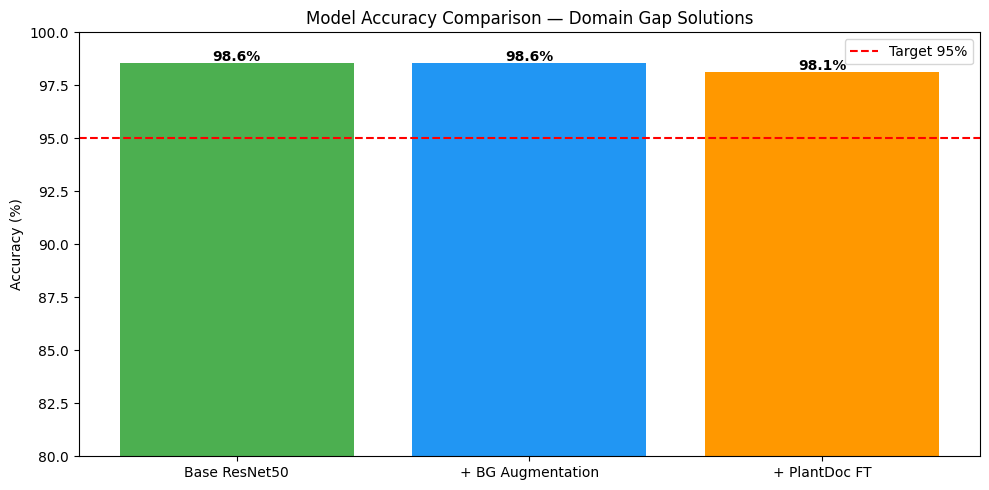

✅ Comparison chart saved!


In [30]:
# ══════════════════════════════════════════════════════
# STEP 14e — Compare All Models
# Shows improvement across all 3 models
# ══════════════════════════════════════════════════════
from tensorflow.keras.models import load_model

def evaluate_model(model, generator, name):
    generator.reset()
    preds, labels = [], []
    for i in range(min(len(generator), 50)):  # Test on 50 batches
        x, y = generator[i]
        p = model.predict(x, verbose=0)
        preds.extend(np.argmax(p, axis=1))
        labels.extend(np.argmax(y, axis=1) if y.ndim > 1 else y.astype(int))
    acc = np.mean(np.array(preds) == np.array(labels)) * 100
    print(f'  {name}: {acc:.2f}%')
    return acc

print('='*55)
print('📊 MODEL COMPARISON — Domain Gap Solutions')
print('='*55)
print('PlantVillage Validation Accuracy:')

results = {}

# Base model
base_path = '/content/drive/MyDrive/crop_disease_model/best_model.keras'
if os.path.exists(base_path):
    m = load_model(base_path)
    results['Base ResNet50'] = evaluate_model(m, val_pv, 'Base ResNet50')
    del m

# Background augmented model
bg_path = '/content/drive/MyDrive/crop_disease_model/best_model_bg.keras'
if os.path.exists(bg_path):
    m = load_model(bg_path)
    results['+ BG Augmentation'] = evaluate_model(m, val_pv, '+ BG Augmentation')
    del m

# PlantDoc fine-tuned model
ft_path = '/content/drive/MyDrive/crop_disease_model/best_model_realworld.keras'
if os.path.exists(ft_path):
    m = load_model(ft_path)
    results['+ PlantDoc FT'] = evaluate_model(m, val_pv, '+ PlantDoc FT')
    del m

print('='*55)

# Plot comparison
if results:
    plt.figure(figsize=(10, 5))
    colors = ['#4CAF50', '#2196F3', '#FF9800']
    bars = plt.bar(results.keys(), results.values(), color=colors[:len(results)])
    plt.axhline(y=95, color='red', linestyle='--', label='Target 95%')
    plt.ylim(80, 100)
    plt.ylabel('Accuracy (%)')
    plt.title('Model Accuracy Comparison — Domain Gap Solutions')
    plt.legend()
    for bar, val in zip(bars, results.values()):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/crop_disease_model/model_comparison.png', dpi=150)
    plt.show()
    print('✅ Comparison chart saved!')


In [31]:
# ══════════════════════════════════════════════════════
# STEP 14f — Save Final Best Model
# Copies the best performing model as the main model
# ══════════════════════════════════════════════════════
import shutil

# Find best model
model_paths = [
    ('/content/drive/MyDrive/crop_disease_model/best_model_realworld.keras', 'PlantDoc Fine-Tuned'),
    ('/content/drive/MyDrive/crop_disease_model/best_model_bg.keras',        'BG Augmented'),
    ('/content/drive/MyDrive/crop_disease_model/best_model.keras',           'Base ResNet50')
]

for path, name in model_paths:
    if os.path.exists(path):
        final_path = '/content/drive/MyDrive/crop_disease_model/final_model.keras'
        shutil.copy2(path, final_path)
        print(f'✅ Final model set to: {name}')
        print(f'✅ Saved as: final_model.keras')
        break

print('\n' + '='*55)
print('🎉 ALL DOMAIN GAP SOLUTIONS COMPLETE — Group 17')
print('='*55)
print('Files saved to Google Drive:')
for f in os.listdir('/content/drive/MyDrive/crop_disease_model'):
    size = os.path.getsize(f'/content/drive/MyDrive/crop_disease_model/{f}')
    print(f'  {f} — {size/1024/1024:.1f} MB')


✅ Final model set to: PlantDoc Fine-Tuned
✅ Saved as: final_model.keras

🎉 ALL DOMAIN GAP SOLUTIONS COMPLETE — Group 17
Files saved to Google Drive:
  best_model.keras — 232.2 MB
  class_names.json — 0.0 MB
  best_model_realworld.keras — 195.1 MB
  final_model.keras — 195.1 MB
  best_model_bg.keras — 227.7 MB
  confusion_matrix_plantvillage.png — 0.3 MB
  model_comparison.png — 0.1 MB
  training_curves.png — 0.1 MB


In [32]:
import os
import shutil

# Check what's in Drive
drive_path = '/content/drive/MyDrive/crop_disease_model'
print("Files in Drive:")
for f in os.listdir(drive_path):
    size = os.path.getsize(f'{drive_path}/{f}')
    print(f"  {f} — {size/1024/1024:.1f} MB")

# Check Colab working directory
print("\nFiles in Colab working:")
for f in os.listdir('/kaggle/working' if os.path.exists('/kaggle/working') else '.'):
    if not f.startswith('.'):
        print(f"  {f}")

Files in Drive:
  best_model.keras — 232.2 MB
  class_names.json — 0.0 MB
  best_model_realworld.keras — 195.1 MB
  final_model.keras — 195.1 MB
  best_model_bg.keras — 227.7 MB
  confusion_matrix_plantvillage.png — 0.3 MB
  model_comparison.png — 0.1 MB
  training_curves.png — 0.1 MB

Files in Colab working:
  drive
  sample_data


In [33]:
from google.colab import files

# Most important files for Flask app
files.download('/content/drive/MyDrive/crop_disease_model/final_model.keras')
files.download('/content/drive/MyDrive/crop_disease_model/class_names.json')

# For presentation slides
files.download('/content/drive/MyDrive/crop_disease_model/model_comparison.png')
files.download('/content/drive/MyDrive/crop_disease_model/training_curves.png')
files.download('/content/drive/MyDrive/crop_disease_model/confusion_matrix_plantvillage.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>